# PMR3404 - Controle I - V2026
# Lab 2: Tutorial sobre Lugar das Raízes

## 1. Introdução

A Figura 1 abaixo ilustra um sistema standard de controle em malha fechada com realimentação
unitária.

<img src="./Figuras/StandardBlock.png" width="60%" height="60%"/>

Sabemos que para esse sistema os pólos são as raízes da equação característica:
$$
1+G(s)H(s)=0.
$$

Usualmente o método é realizado em função de um único parâmetro $K_p \in \mathbb{R}^+$.
É conveniente que $K_p$ seja a constante proporcional $K_p$ do controlador PID.

Fatora-se nesse caso a constante $K_p$ do controlador $H(s)$. A equação característica pode ser
escrita da seguinte forma:
$$
1 + K_p G(s)H(s)=0.
$$

O biblioteca Control Systems da Linguagem Python possui a função rlocus() que calcula e constrói o gráfico do lugar das raízes.
O método de solução utilizado consiste em discretizar o valor de $0 < K_p <\infty$ e estimar para cada valor de $K_p$ os pólos da equação característica.

## 2. Características no domínio do tempo, lugares geométricos

O projeto de um sistema de controle em malha fechada está diretamente associado ao posicionamento dos pólos e zeros do sistema.

Dado um sistema descrito por equações diferenciais ou função de transferência é bastante difícil prever
quais serão suas características no domínio do tempo. Em geral é necessário realizar uma simulação numérica
do sistema.

Uma possível tática para previsão das características no domínio do tempo consiste em utilizar uma
aproximação de 2a. ordem do sistema conisderando o par de pólos complexos conjugados dominantes do sistema.

Suponha o seguinte sistema de 2a. ordem:

$$
G(s)= \frac{\omega_n^2}{s(s+2\zeta\omega_n)}.
$$
      
Um sistema de controle em malha fechada com $G(s)$ pode ser
descrito como:

$$
\frac{Y(s)}{R(s)} = \frac{G(s)}{1+G(s)} = \frac{\omega_n^2}{s^2+2\zeta\omega_n^2s+\omega_n^2}.
$$


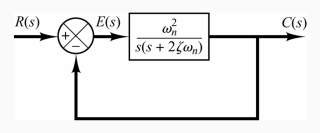

O par de pólos complexos conjugados estáveis (semi-plano esquerdo) pode ser escrito como:

$$
s = -\sigma \pm j \omega_d
$$

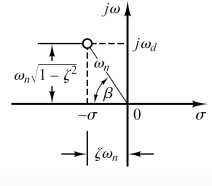

As características no domínio do tempo para esse sistema estão relacionados a lugares geométricos
dos parâmetros no plano $s$.

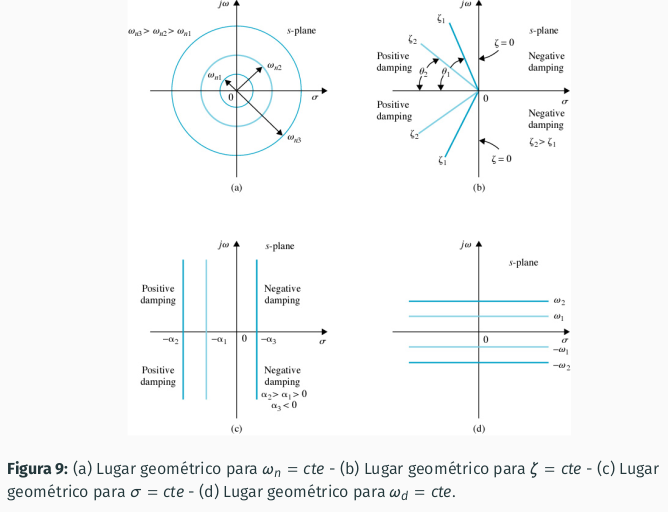

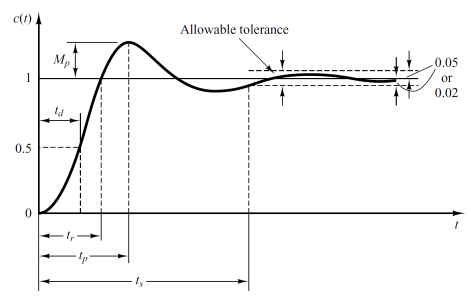

Os requisitos de controle no domínio do tempo mais utilizados são:

- Máximo sobressinal:
$$
M_p = \exp^{- \left( \frac{\zeta}{\sqrt{1-\zeta^2}} \right) \pi}.
$$

Para um $M_p<M_p^{\max}$ implica em um coeficiente de amortecimento $\zeta > \zeta_{\lim}$
o que resulta em $\beta<\beta_{\lim}$.
No plano $s$ isso pode ser representado através do seguinte lugar geométrico.

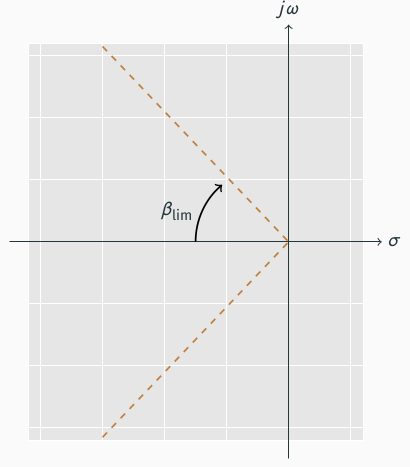

- tempo de acomodação (2%):
$$
t_s = \frac{4}{\zeta\omega_n}
$$

Como $\sigma=\zeta\omega_n$ o requisito definido como $t_s<t_s^\max$ implica em
$\sigma > \frac{4}{t_s^\max}$

No plano $s$ isso pode ser representado através do seguinte lugar geométrico.

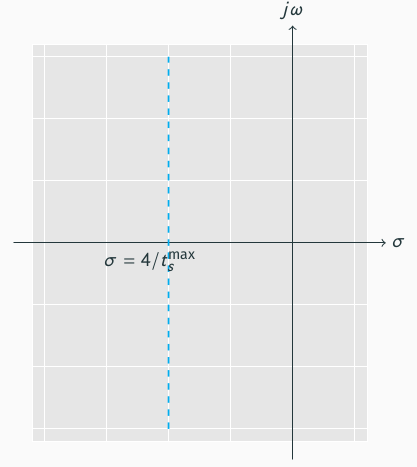

- tempo de subida:
$$
t_r = \frac{\pi - \beta}{\omega_d}
$$

A equação acima não define um lugar geométrico trivial, uma possível aproximação pode ser dada por:

$$
t_r = 1.8/\omega_n
$$

Nesse caso, para $t_r<t_r^\max$ temos $\omega_n>1.8/t_r^\max$

No plano $s$ isso pode ser representado através do seguinte lugar geométrico.

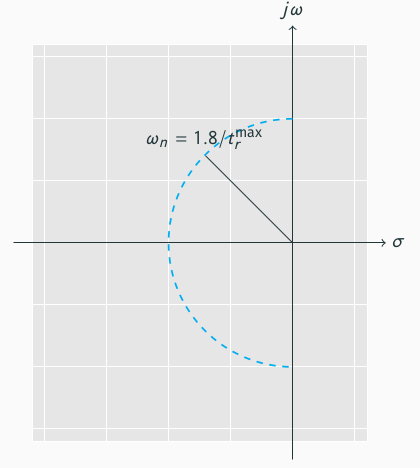


## 3. Exemplos de utilização de lugar das raízes utilizando Python control system toolbox

Pacotes utilizados

In [3]:
# Pacotes utilizados
import numpy as np
import matplotlib.pyplot as plt
import control.matlab as co

Tipos de gráficos permitidos pelo matplotlib

In [17]:
# Tipos de graficos
# 1. Abre uma janela interativa
%matplotlib qt
# 2. Grafico e'colocado inline mas com interacao
#%matplotlib notebook
# 3. Grafico e'colocado inline mas sem interacao
#%matplotlib inline             
# Fecha todas as janelas graficas
plt.close('all')

### Método 1: primeiro escolhe-se $K_p$ no lugar das raízes depois analisa-se o resultado

Aqui utilizaremos a planta
$$
G(s) = \frac{1}{s(s+2)}
$$
e controlador Proporcional
$$
H(s)=K_p
$$

In [18]:
s = co.tf('s')
G = 1/(s*(s+2))
H = 1
GH = G*H
print('GH = ',GH)
[rlist,klist] = co.rlocus(GH)
plt.show()

GH =  <TransferFunction>: sys[79]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

      1
  ---------
  s^2 + 2 s


C:\Users\gugaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\control\rlocus.py:202: FutureWarning: root_locus() return value of roots, gains is deprecated; use root_locus_map()
  warnings.warn(


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Escolhido o valor de $K_p$ através do método do lugar das raízes, agora podemos caracterizar o desempenho do sistema de controle em malha fechada.

-------------
FT DE MALHA ABERTA GH(s) = G(s)*H(s) = 
<TransferFunction>: sys[52]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     4.3
  ---------
  s^2 + 2 s
-------------
POLOS E ZEROS DE MALHA ABERTA
Polos de GH(s) =  [-2.+0.j  0.+0.j]
Zeros de GH(s) =  []
-------------
FT DE MALHA FECHADA GH(s)/(1+GH(s))
<TransferFunction>: sys[54]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        4.3
  ---------------
  s^2 + 2 s + 4.3
-------------
POLOS E ZEROS DE MALHA FECHADA
Polos da planta cloop(s) =  GH(s)/(1+GH(s)) =  [-1.+1.81659021j -1.-1.81659021j]
Zeros da planta cloop(s) =  GH(s)/(1+GH(s)) =  []
-------------
COEF. DE AMORTECIMENTO E FREQ. NATURAL
_____Polos____________zeta_______omegan
    Eigenvalue (pole)       Damping     Frequency
        -1    +1.817j        0.4822         2.074
        -1    -1.817j        0.4822         2.074
-------------
CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA
tempo de subida tr =  0.77 seg
tempo de acomodacao ts =  3.98 seg
maximo sobresinal Mp

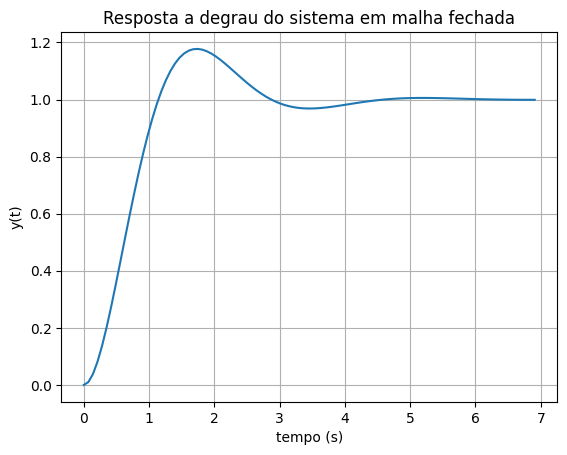

In [14]:
# Mudanca para graficos inline
%matplotlib inline
# Valor de Kp escolhido acima
Kp = 4.3
# Redefinicao da FT de malha aberta
GH = Kp*GH
print('-------------')
print('FT DE MALHA ABERTA GH(s) = G(s)*H(s) = ')
print(GH)
print('-------------')
print('POLOS E ZEROS DE MALHA ABERTA')
print('Polos de GH(s) = ', co.pole(GH))
print('Zeros de GH(s) = ', co.zero(GH))
# Funcao de transferencia em malha fechada
cloop = co.feedback(GH,1)
print('-------------')
print('FT DE MALHA FECHADA GH(s)/(1+GH(s))')
print(cloop)
print('-------------')
print('POLOS E ZEROS DE MALHA FECHADA')
print('Polos da planta cloop(s) =  GH(s)/(1+GH(s)) = ', co.pole(cloop))
print('Zeros da planta cloop(s) =  GH(s)/(1+GH(s)) = ', co.zero(cloop))
print('-------------')
print('COEF. DE AMORTECIMENTO E FREQ. NATURAL')
print('_____Polos____________zeta_______omegan')
co.damp(cloop)
# Calcula as caracteristicas da resposta transitoria
#  stepinfo(sys, T=None, SettlingTimeThreshold=0.02, RiseTimeLimits=(0.1,0.9))
#  S: a dictionary containing:
#        RiseTime: Time from 10% to 90% of the steady-state value.
#        SettlingTime: Time to enter inside a default error of 2%
#        SettlingMin: Minimum value after RiseTime
#        SettlingMax: Maximum value after RiseTime
#        Overshoot: Percentage of the Peak relative to steady value
#        Undershoot: Percentage of undershoot
#        Peak: Absolute peak value
#        PeakTime: time of the Peak
#        SteadyStateValue: Steady-state value
S = co.stepinfo(cloop)
print('-------------')
print('CARACTERISTICAS DA RESPOSTA TRANSITORIA DO SISTEMA')
print('tempo de subida tr = ','%.2f' % S['RiseTime'],'seg')
print('tempo de acomodacao ts = ','%.2f' % S['SettlingTime'],'seg')
print('maximo sobresinal Mp = ',S['Overshoot'])
print('valor de pico thetaomax = ','%.2f' % S['Peak'])
print('instante de pico tp = ','%.2f' % S['PeakTime'],'seg')
print('valor de regime estacionario thetaoss = ','%.2f' % S['SteadyStateValue'])
# Grafico da resposta a degrau unitario
y,t = co.step(cloop)
plt.plot(t,y)
plt.title('Resposta a degrau do sistema em malha fechada')
plt.xlabel('tempo (s)')
plt.ylabel('y(t)')
plt.grid()

### Método 2: utilização de sisotool

Nesse exemplo utilizaremos um controlador PI
$$
H(s)=K_p(1+1/T_i)
$$
para uma planta
$$
G(s)=\frac{1}{s+2}
$$

Como o lugar das raízes deve ser função de um único parâmetro
devemos aqui escolher um valor a priori para o tempo integral $T_i$.
Mas qual valor ?

Utilizaremos dois valores diferentes como exemplo.

### Escolha 1

$$
T_i = 3
$$

In [ ]:
%matplotlib
s = co.tf('s')
G = 1/(s+2)
Ti = 3
H = (1+1/(Ti*s))
GH = G*H
print('GH = ',GH)
co.sisotool(GH)

### Escolha 2

$$
T_i = 1/4
$$

In [ ]:
%matplotlib
s = co.tf('s')
G = 1/(s+2)
Ti = 1/4
H = (1+1/(Ti*s))
GH = G*H
print('GH = ',GH)
co.sisotool(GH)